# Control and Trajectory Optimization

Differentiable programming enables powerful approaches to control and trajectory optimization: computing optimal control inputs by differentiating through the system dynamics.

**Topics covered:**
1. Differentiating through dynamics
2. Open-loop trajectory optimization
3. PID tuning with gradients
4. Model Predictive Control (MPC) basics
5. Chemical engineering application: CSTR control

In [1]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
from jax import lax
import matplotlib.pyplot as plt
import numpy as np
from functools import partial
import optax
import diffrax

jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")

Metal device set to: Apple M4 Pro
JAX version: 0.8.1


W0000 00:00:1767134404.271448 4112751 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767134404.280128 4112751 service.cc:145] XLA service 0x600003c00100 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767134404.280137 4112751 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767134404.281097 4112751 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767134404.281104 4112751 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


## 1. Differentiating Through Dynamics

Consider a discrete-time dynamical system:

$$x_{t+1} = f(x_t, u_t)$$

Where:
- $x_t$: state at time $t$
- $u_t$: control input at time $t$

Given a cost function over a trajectory:

$$J = \sum_{t=0}^{T} c(x_t, u_t)$$

We can compute $\frac{\partial J}{\partial u_{0:T}}$ using autodiff through the simulation!

In [2]:
# Simple example: 1D system

def dynamics(x, u):
    """Simple 1D dynamics: x_{t+1} = 0.9*x + u"""
    return 0.9 * x + u

def simulate(x0, controls):
    """
    Simulate trajectory given initial state and control sequence.
    
    Returns: trajectory of states [x0, x1, ..., xT]
    """
    def step(x, u):
        x_next = dynamics(x, u)
        return x_next, x_next
    
    _, trajectory = lax.scan(step, x0, controls)
    return jnp.concatenate([jnp.array([x0]), trajectory])

def trajectory_cost(controls, x0, x_target):
    """
    Cost: sum of squared deviations from target + control effort.
    """
    trajectory = simulate(x0, controls)
    state_cost = jnp.sum((trajectory - x_target) ** 2)
    control_cost = 0.1 * jnp.sum(controls ** 2)
    return state_cost + control_cost

# Example
x0 = 0.0
x_target = 1.0
T = 20
controls = jnp.zeros(T)  # Initial: no control

# Compute gradient of cost w.r.t. controls
cost = trajectory_cost(controls, x0, x_target)
gradients = grad(trajectory_cost)(controls, x0, x_target)

print(f"Initial cost (zero controls): {cost:.4f}")
print(f"Gradient shape: {gradients.shape}")
print(f"First few gradients: {gradients[:5]}")
print("\nNegative gradients early → need positive control to reach target!")

Initial cost (zero controls): 21.0000
Gradient shape: (20,)
First few gradients: [-17.56846691 -17.29829656 -16.99810729 -16.66456366 -16.29395962]

Negative gradients early → need positive control to reach target!


## 2. Open-Loop Trajectory Optimization

**Goal:** Find the optimal control sequence $u_{0:T}$ that minimizes the trajectory cost.

With gradients, we can use gradient descent (or better optimizers like L-BFGS).

In [3]:
def optimize_trajectory(x0, x_target, T, n_iter=200, lr=0.1):
    """
    Optimize control sequence to drive system from x0 to x_target.
    """
    controls = jnp.zeros(T)
    optimizer = optax.adam(learning_rate=lr)
    opt_state = optimizer.init(controls)
    
    @jit
    def update(controls, opt_state):
        loss, grads = jax.value_and_grad(trajectory_cost)(controls, x0, x_target)
        updates, opt_state = optimizer.update(grads, opt_state)
        controls = optax.apply_updates(controls, updates)
        return controls, opt_state, loss
    
    losses = []
    for i in range(n_iter):
        controls, opt_state, loss = update(controls, opt_state)
        losses.append(float(loss))
    
    return controls, losses

# Optimize
x0 = 0.0
x_target = 1.0
T = 20

optimal_controls, losses = optimize_trajectory(x0, x_target, T)
optimal_trajectory = simulate(x0, optimal_controls)

print(f"Final cost: {losses[-1]:.6f}")
print(f"Final state: {optimal_trajectory[-1]:.4f} (target: {x_target})")

Final cost: 1.111823
Final state: 0.9908 (target: 1.0)


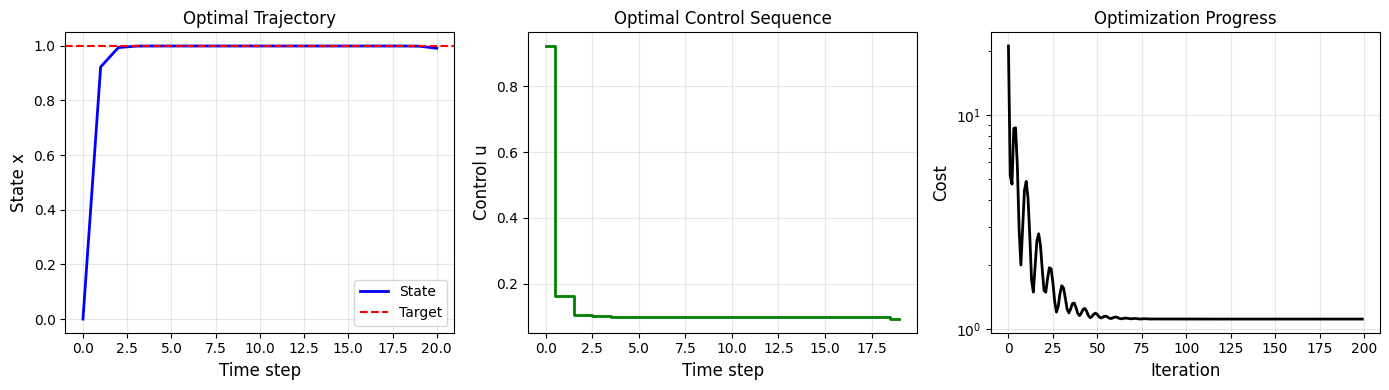

In [4]:
# Visualize results

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Trajectory
t = jnp.arange(T + 1)
axes[0].plot(t, optimal_trajectory, 'b-', linewidth=2, label='State')
axes[0].axhline(x_target, color='r', linestyle='--', label='Target')
axes[0].set_xlabel('Time step', fontsize=12)
axes[0].set_ylabel('State x', fontsize=12)
axes[0].set_title('Optimal Trajectory', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Controls
axes[1].step(range(T), optimal_controls, 'g-', linewidth=2, where='mid')
axes[1].set_xlabel('Time step', fontsize=12)
axes[1].set_ylabel('Control u', fontsize=12)
axes[1].set_title('Optimal Control Sequence', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Loss curve
axes[2].semilogy(losses, 'k-', linewidth=2)
axes[2].set_xlabel('Iteration', fontsize=12)
axes[2].set_ylabel('Cost', fontsize=12)
axes[2].set_title('Optimization Progress', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. CSTR Control Problem

Consider a continuous stirred-tank reactor (CSTR) with first-order reaction A → B:

$$\frac{dC_A}{dt} = \frac{F}{V}(C_{A,in} - C_A) - k(T)C_A$$

$$\frac{dT}{dt} = \frac{F}{V}(T_{in} - T) + \frac{(-\Delta H)}{\rho C_p}k(T)C_A + \frac{UA}{V\rho C_p}(T_c - T)$$

Where $T_c$ (coolant temperature) is the control input.

In [5]:
# CSTR parameters
cstr_params = {
    'F': 1.0,        # Flow rate (L/s)
    'V': 100.0,      # Volume (L)
    'C_Ain': 1.0,    # Inlet concentration (mol/L)
    'T_in': 300.0,   # Inlet temperature (K)
    'k0': 7.2e10,    # Pre-exponential factor (1/s)
    'Ea': 72750.0,   # Activation energy (J/mol)
    'R': 8.314,      # Gas constant (J/mol/K)
    'dH': -50000.0,  # Heat of reaction (J/mol)
    'rho': 1000.0,   # Density (kg/L)
    'Cp': 4.0,       # Heat capacity (J/kg/K)
    'UA': 50.0,      # Heat transfer coefficient (W/K)
}

def cstr_dynamics(state, Tc, params):
    """
    CSTR dynamics.
    state = [C_A, T]
    Tc = coolant temperature (control)
    """
    C_A, T = state
    
    # Reaction rate
    k = params['k0'] * jnp.exp(-params['Ea'] / (params['R'] * T))
    
    # Mass balance
    dC_A = (params['F'] / params['V']) * (params['C_Ain'] - C_A) - k * C_A
    
    # Energy balance
    heat_reaction = (-params['dH']) / (params['rho'] * params['Cp']) * k * C_A
    heat_transfer = (params['UA'] / (params['V'] * params['rho'] * params['Cp'])) * (Tc - T)
    dT = (params['F'] / params['V']) * (params['T_in'] - T) + heat_reaction + heat_transfer
    
    return jnp.array([dC_A, dT])

# Test steady state
state0 = jnp.array([0.5, 350.0])  # Initial guess
Tc_ss = 300.0
print(f"Initial state: C_A = {state0[0]:.3f} mol/L, T = {state0[1]:.1f} K")
print(f"Dynamics at initial state: {cstr_dynamics(state0, Tc_ss, cstr_params)}")

Initial state: C_A = 0.500 mol/L, T = 350.0 K
Dynamics at initial state: [-0.49453662  5.73795781]


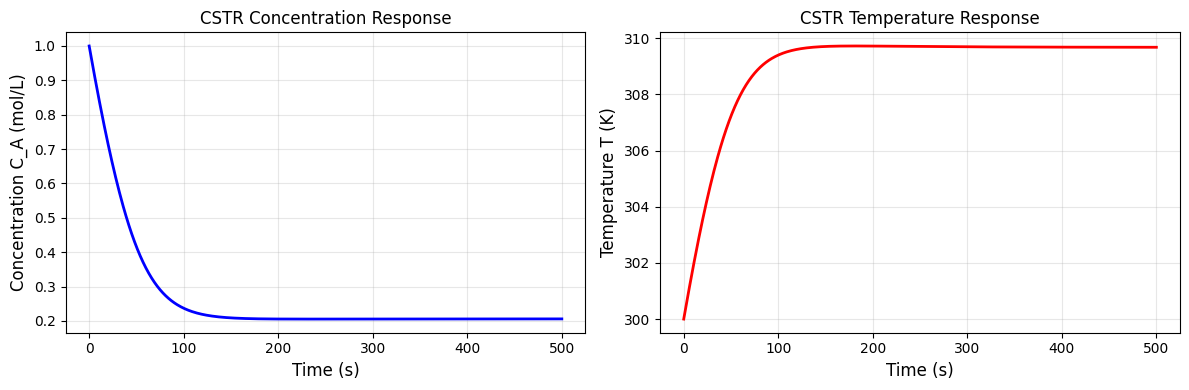

Steady state: C_A = 0.2060 mol/L, T = 309.68 K


In [6]:
# Simulate CSTR with Euler integration

def simulate_cstr(state0, controls, dt, params):
    """
    Simulate CSTR with given control sequence.
    
    controls: array of coolant temperatures [Tc_0, Tc_1, ...]
    dt: time step
    
    Returns: trajectory of states
    """
    def euler_step(state, Tc):
        dstate = cstr_dynamics(state, Tc, params)
        state_next = state + dt * dstate
        return state_next, state_next
    
    _, trajectory = lax.scan(euler_step, state0, controls)
    return jnp.vstack([state0, trajectory])

# Test simulation
state0 = jnp.array([1.0, 300.0])  # Start at inlet conditions
dt = 1.0  # 1 second time step
T_sim = 500  # Total time (s)
n_steps = int(T_sim / dt)

# Constant coolant temperature
Tc_constant = 290.0 * jnp.ones(n_steps)
trajectory = simulate_cstr(state0, Tc_constant, dt, cstr_params)

# Plot
t = jnp.arange(n_steps + 1) * dt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t, trajectory[:, 0], 'b-', linewidth=2)
axes[0].set_xlabel('Time (s)', fontsize=12)
axes[0].set_ylabel('Concentration C_A (mol/L)', fontsize=12)
axes[0].set_title('CSTR Concentration Response', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, trajectory[:, 1], 'r-', linewidth=2)
axes[1].set_xlabel('Time (s)', fontsize=12)
axes[1].set_ylabel('Temperature T (K)', fontsize=12)
axes[1].set_title('CSTR Temperature Response', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Steady state: C_A = {trajectory[-1, 0]:.4f} mol/L, T = {trajectory[-1, 1]:.2f} K")

## 4. CSTR Trajectory Optimization

**Goal:** Find the coolant temperature sequence that drives the CSTR to a target steady state while minimizing overshoot and control effort.

In [7]:
def cstr_trajectory_cost(controls, state0, target_state, dt, params, 
                         Q_state=None, R_control=0.001):
    """
    Trajectory cost for CSTR control.
    
    Q_state: weights for state deviation [weight_C_A, weight_T]
    R_control: weight for control effort
    """
    if Q_state is None:
        Q_state = jnp.array([100.0, 1.0])  # Care more about concentration
    
    trajectory = simulate_cstr(state0, controls, dt, params)
    
    # State deviation cost
    deviations = trajectory - target_state
    state_cost = jnp.sum(Q_state * deviations ** 2)
    
    # Control effort (penalize changes in Tc)
    control_changes = jnp.diff(controls)
    control_cost = R_control * jnp.sum(control_changes ** 2)
    
    # Bound constraints (soft)
    Tc_min, Tc_max = 260.0, 350.0
    lb_violation = jnp.sum(jax.nn.relu(Tc_min - controls) ** 2)
    ub_violation = jnp.sum(jax.nn.relu(controls - Tc_max) ** 2)
    
    return state_cost + control_cost + 1000 * (lb_violation + ub_violation)

# Define control problem
state0 = jnp.array([0.8, 320.0])  # Start at this operating point
target_state = jnp.array([0.3, 350.0])  # Target: lower concentration, higher T
dt = 1.0
T_horizon = 200
n_steps = int(T_horizon / dt)

# Initial control: constant at some reasonable value
controls_init = 280.0 * jnp.ones(n_steps)

print(f"Control horizon: {T_horizon} s ({n_steps} steps)")
print(f"Initial state: C_A = {state0[0]:.2f}, T = {state0[1]:.1f} K")
print(f"Target state:  C_A = {target_state[0]:.2f}, T = {target_state[1]:.1f} K")
print(f"Initial cost: {cstr_trajectory_cost(controls_init, state0, target_state, dt, cstr_params):.2f}")

Control horizon: 200 s (200 steps)
Initial state: C_A = 0.80, T = 320.0 K
Target state:  C_A = 0.30, T = 350.0 K


Initial cost: 209301.18


In [8]:
# Optimize control trajectory

def optimize_cstr_control(state0, target_state, n_steps, dt, params, n_iter=300, lr=0.5):
    """
    Optimize coolant temperature trajectory.
    """
    controls = 300.0 * jnp.ones(n_steps)  # Initial guess
    
    optimizer = optax.adam(learning_rate=lr)
    opt_state = optimizer.init(controls)
    
    @jit
    def update(controls, opt_state):
        loss, grads = jax.value_and_grad(cstr_trajectory_cost)(
            controls, state0, target_state, dt, params
        )
        updates, opt_state = optimizer.update(grads, opt_state)
        controls = optax.apply_updates(controls, updates)
        return controls, opt_state, loss
    
    losses = []
    for i in range(n_iter):
        controls, opt_state, loss = update(controls, opt_state)
        losses.append(float(loss))
        
        if i % 50 == 0:
            print(f"Iteration {i}: cost = {loss:.2f}")
    
    return controls, losses

optimal_controls, losses = optimize_cstr_control(
    state0, target_state, n_steps, dt, cstr_params
)

print(f"\nFinal cost: {losses[-1]:.2f}")

Iteration 0: cost = 207175.73
Iteration 50: cost = 204542.18
Iteration 100: cost = 201941.10
Iteration 150: cost = 202398.17
Iteration 200: cost = 202372.65
Iteration 250: cost = 202339.09

Final cost: 202302.29


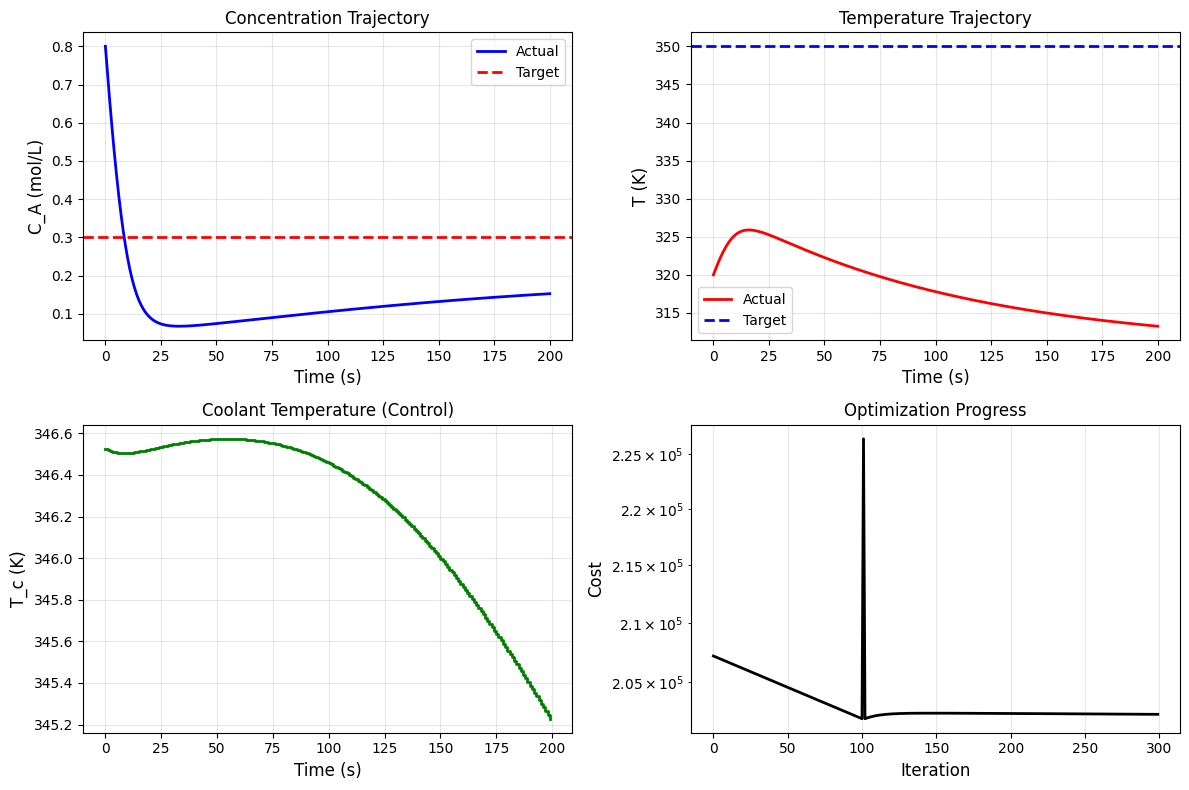

Final state: C_A = 0.1527, T = 313.25 K
Target:      C_A = 0.3000, T = 350.00 K


In [9]:
# Simulate with optimal controls
optimal_trajectory = simulate_cstr(state0, optimal_controls, dt, cstr_params)
t = jnp.arange(n_steps + 1) * dt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Concentration
axes[0, 0].plot(t, optimal_trajectory[:, 0], 'b-', linewidth=2, label='Actual')
axes[0, 0].axhline(target_state[0], color='r', linestyle='--', linewidth=2, label='Target')
axes[0, 0].set_xlabel('Time (s)', fontsize=12)
axes[0, 0].set_ylabel('C_A (mol/L)', fontsize=12)
axes[0, 0].set_title('Concentration Trajectory', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Temperature
axes[0, 1].plot(t, optimal_trajectory[:, 1], 'r-', linewidth=2, label='Actual')
axes[0, 1].axhline(target_state[1], color='b', linestyle='--', linewidth=2, label='Target')
axes[0, 1].set_xlabel('Time (s)', fontsize=12)
axes[0, 1].set_ylabel('T (K)', fontsize=12)
axes[0, 1].set_title('Temperature Trajectory', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Control input
axes[1, 0].step(t[:-1], optimal_controls, 'g-', linewidth=2, where='post')
axes[1, 0].set_xlabel('Time (s)', fontsize=12)
axes[1, 0].set_ylabel('T_c (K)', fontsize=12)
axes[1, 0].set_title('Coolant Temperature (Control)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Loss curve
axes[1, 1].semilogy(losses, 'k-', linewidth=2)
axes[1, 1].set_xlabel('Iteration', fontsize=12)
axes[1, 1].set_ylabel('Cost', fontsize=12)
axes[1, 1].set_title('Optimization Progress', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final state: C_A = {optimal_trajectory[-1, 0]:.4f}, T = {optimal_trajectory[-1, 1]:.2f} K")
print(f"Target:      C_A = {target_state[0]:.4f}, T = {target_state[1]:.2f} K")

## 5. PID Tuning with Gradients

Traditional PID tuning uses heuristics (Ziegler-Nichols, etc.). With differentiable simulation, we can **directly optimize** PID gains!

In [10]:
def pid_controller(error_integral, error_prev, error, Kp, Ki, Kd, dt):
    """
    PID controller.
    
    Returns: control output, new integral, current error (for next step)
    """
    # Update integral
    integral_new = error_integral + error * dt
    
    # Derivative
    derivative = (error - error_prev) / dt
    
    # PID output
    u = Kp * error + Ki * integral_new + Kd * derivative
    
    return u, integral_new, error

def simulate_cstr_pid(state0, target_T, pid_gains, dt, n_steps, params):
    """
    Simulate CSTR with PID temperature control.
    
    pid_gains: [Kp, Ki, Kd]
    target_T: temperature setpoint
    """
    Kp, Ki, Kd = pid_gains
    
    def step(carry, _):
        state, error_integral, error_prev = carry
        
        # Current error
        error = target_T - state[1]  # T error
        
        # PID output
        Tc_adjustment, error_integral_new, _ = pid_controller(
            error_integral, error_prev, error, Kp, Ki, Kd, dt
        )
        
        # Control with bounds
        Tc_base = 290.0  # Nominal coolant temperature
        Tc = jnp.clip(Tc_base + Tc_adjustment, 260.0, 350.0)
        
        # Dynamics step
        dstate = cstr_dynamics(state, Tc, params)
        state_new = state + dt * dstate
        
        return (state_new, error_integral_new, error), (state_new, Tc)
    
    initial_carry = (state0, 0.0, 0.0)  # state, integral, prev_error
    _, (trajectory, controls) = lax.scan(step, initial_carry, None, length=n_steps)
    
    trajectory = jnp.vstack([state0, trajectory])
    
    return trajectory, controls

# Test with initial PID gains
state0 = jnp.array([0.5, 320.0])
target_T = 350.0
pid_gains_init = jnp.array([1.0, 0.01, 0.0])  # Kp, Ki, Kd
dt = 1.0
n_steps = 300

trajectory, controls = simulate_cstr_pid(state0, target_T, pid_gains_init, dt, n_steps, cstr_params)

print(f"Initial PID gains: Kp={pid_gains_init[0]}, Ki={pid_gains_init[1]}, Kd={pid_gains_init[2]}")
print(f"Final T: {trajectory[-1, 1]:.2f} K (target: {target_T} K)")

Initial PID gains: Kp=1.0, Ki=0.01, Kd=0.0
Final T: 311.35 K (target: 350.0 K)


In [11]:
def pid_cost(pid_gains, state0, target_T, dt, n_steps, params):
    """
    Cost function for PID tuning.
    
    Penalizes:
    - Steady-state error
    - Overshoot
    - Settling time (deviation from target)
    - Control effort
    """
    trajectory, controls = simulate_cstr_pid(state0, target_T, pid_gains, dt, n_steps, params)
    
    # Temperature error
    T_trajectory = trajectory[:, 1]
    T_error = T_trajectory - target_T
    
    # Integrated squared error
    ise = jnp.sum(T_error ** 2) * dt
    
    # Overshoot penalty
    overshoot = jnp.maximum(0, T_trajectory - target_T - 5.0)  # Allow 5K overshoot
    overshoot_penalty = 10.0 * jnp.sum(overshoot ** 2)
    
    # Control effort
    control_effort = 0.01 * jnp.sum(jnp.diff(controls) ** 2)
    
    return ise + overshoot_penalty + control_effort

# Optimize PID gains
def optimize_pid(state0, target_T, dt, n_steps, params, n_iter=200, lr=0.01):
    """
    Optimize PID gains using gradient descent.
    """
    pid_gains = jnp.array([0.5, 0.001, 0.1])  # Initial guess
    
    optimizer = optax.adam(learning_rate=lr)
    opt_state = optimizer.init(pid_gains)
    
    @jit
    def update(pid_gains, opt_state):
        loss, grads = jax.value_and_grad(pid_cost)(
            pid_gains, state0, target_T, dt, n_steps, params
        )
        updates, opt_state = optimizer.update(grads, opt_state)
        pid_gains = optax.apply_updates(pid_gains, updates)
        # Keep gains positive
        pid_gains = jnp.maximum(pid_gains, 0.0)
        return pid_gains, opt_state, loss
    
    losses = []
    for i in range(n_iter):
        pid_gains, opt_state, loss = update(pid_gains, opt_state)
        losses.append(float(loss))
        
        if i % 50 == 0:
            print(f"Iteration {i}: cost = {loss:.2f}, Kp={pid_gains[0]:.4f}, Ki={pid_gains[1]:.6f}, Kd={pid_gains[2]:.4f}")
    
    return pid_gains, losses

optimal_pid, pid_losses = optimize_pid(state0, target_T, dt, n_steps, cstr_params)
print(f"\nOptimal PID: Kp={optimal_pid[0]:.4f}, Ki={optimal_pid[1]:.6f}, Kd={optimal_pid[2]:.4f}")

Iteration 0: cost = 374602.21, Kp=0.5100, Ki=0.011000, Kd=0.1100
Iteration 50: cost = 366536.12, Kp=0.7231, Ki=0.094622, Kd=0.5670
Iteration 100: cost = 366454.46, Kp=0.8791, Ki=0.107200, Kd=0.9237
Iteration 150: cost = 366403.82, Kp=1.0307, Ki=0.116946, Kd=0.9823

Optimal PID: Kp=1.1668, Ki=0.124401, Kd=0.9027


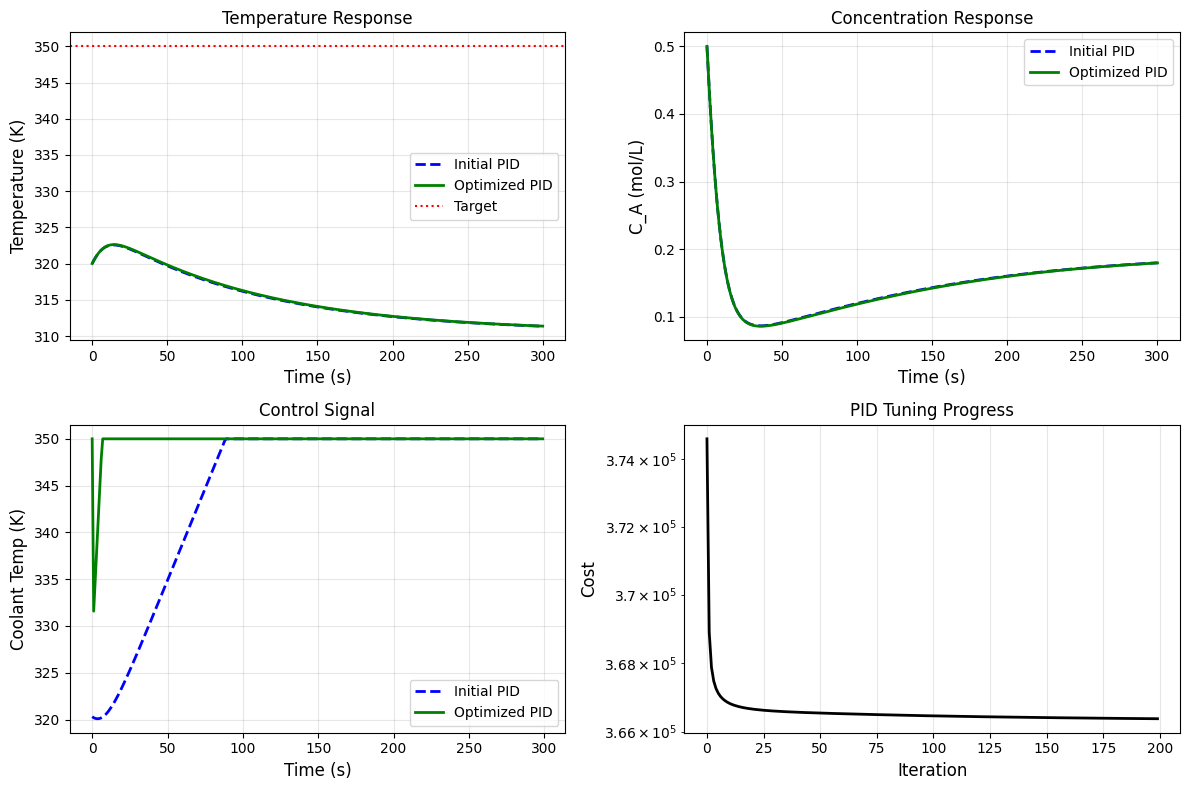


Comparison:
  Initial PID: Kp=1.00, Ki=0.0100, Kd=0.00
  Optimal PID: Kp=1.17, Ki=0.1244, Kd=0.90


In [12]:
# Compare initial vs optimized PID

trajectory_init, controls_init = simulate_cstr_pid(state0, target_T, pid_gains_init, dt, n_steps, cstr_params)
trajectory_opt, controls_opt = simulate_cstr_pid(state0, target_T, optimal_pid, dt, n_steps, cstr_params)

t = jnp.arange(n_steps + 1) * dt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Temperature response
axes[0, 0].plot(t, trajectory_init[:, 1], 'b--', linewidth=2, label='Initial PID')
axes[0, 0].plot(t, trajectory_opt[:, 1], 'g-', linewidth=2, label='Optimized PID')
axes[0, 0].axhline(target_T, color='r', linestyle=':', label='Target')
axes[0, 0].set_xlabel('Time (s)', fontsize=12)
axes[0, 0].set_ylabel('Temperature (K)', fontsize=12)
axes[0, 0].set_title('Temperature Response', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Concentration response
axes[0, 1].plot(t, trajectory_init[:, 0], 'b--', linewidth=2, label='Initial PID')
axes[0, 1].plot(t, trajectory_opt[:, 0], 'g-', linewidth=2, label='Optimized PID')
axes[0, 1].set_xlabel('Time (s)', fontsize=12)
axes[0, 1].set_ylabel('C_A (mol/L)', fontsize=12)
axes[0, 1].set_title('Concentration Response', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Control signals
axes[1, 0].plot(t[:-1], controls_init, 'b--', linewidth=2, label='Initial PID')
axes[1, 0].plot(t[:-1], controls_opt, 'g-', linewidth=2, label='Optimized PID')
axes[1, 0].set_xlabel('Time (s)', fontsize=12)
axes[1, 0].set_ylabel('Coolant Temp (K)', fontsize=12)
axes[1, 0].set_title('Control Signal', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# PID tuning progress
axes[1, 1].semilogy(pid_losses, 'k-', linewidth=2)
axes[1, 1].set_xlabel('Iteration', fontsize=12)
axes[1, 1].set_ylabel('Cost', fontsize=12)
axes[1, 1].set_title('PID Tuning Progress', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nComparison:")
print(f"  Initial PID: Kp={pid_gains_init[0]:.2f}, Ki={pid_gains_init[1]:.4f}, Kd={pid_gains_init[2]:.2f}")
print(f"  Optimal PID: Kp={optimal_pid[0]:.2f}, Ki={optimal_pid[1]:.4f}, Kd={optimal_pid[2]:.2f}")

## 6. Model Predictive Control (MPC) Basics

MPC solves an optimization problem at each time step:
1. Predict future trajectory over horizon $N$
2. Optimize control sequence $u_0, u_1, ..., u_{N-1}$
3. Apply only $u_0$
4. Repeat at next step

With differentiable dynamics, we can use gradient descent for the inner optimization.

In [13]:
def mpc_step(state, target, horizon, dt, params, n_opt_iter=50):
    """
    Single MPC optimization step.
    
    Returns: optimal first control action
    """
    # Initialize control sequence (warm start from previous could improve this)
    controls = 290.0 * jnp.ones(horizon)
    
    def mpc_cost(controls):
        return cstr_trajectory_cost(controls, state, target, dt, params, 
                                     Q_state=jnp.array([100.0, 1.0]), R_control=0.01)
    
    # Quick optimization
    optimizer = optax.adam(learning_rate=1.0)
    opt_state = optimizer.init(controls)
    
    for _ in range(n_opt_iter):
        loss, grads = jax.value_and_grad(mpc_cost)(controls)
        updates, opt_state = optimizer.update(grads, opt_state)
        controls = optax.apply_updates(controls, updates)
        # Clip to bounds
        controls = jnp.clip(controls, 260.0, 350.0)
    
    return controls[0], loss

def simulate_mpc(state0, target, dt, n_steps, horizon, params):
    """
    Run MPC simulation.
    """
    states = [state0]
    controls = []
    
    state = state0
    for i in range(n_steps):
        # Solve MPC
        u_opt, _ = mpc_step(state, target, horizon, dt, params)
        
        # Apply control
        controls.append(float(u_opt))
        
        # Simulate one step
        dstate = cstr_dynamics(state, u_opt, params)
        state = state + dt * dstate
        states.append(state)
        
        if i % 20 == 0:
            print(f"Step {i}: T = {state[1]:.1f} K, Tc = {u_opt:.1f} K")
    
    return jnp.array(states), jnp.array(controls)

# Run MPC
print("Running MPC (this may take a moment)...")
state0 = jnp.array([0.5, 320.0])
target = jnp.array([0.3, 350.0])
dt = 2.0  # Larger time step for MPC
n_mpc_steps = 100
horizon = 20  # Look-ahead horizon

mpc_states, mpc_controls = simulate_mpc(state0, target, dt, n_mpc_steps, horizon, cstr_params)

Running MPC (this may take a moment)...


Step 0: T = 320.8 K, Tc = 340.0 K


Step 20: T = 320.5 K, Tc = 340.0 K


Step 40: T = 317.3 K, Tc = 340.0 K


Step 60: T = 315.1 K, Tc = 340.0 K


Step 80: T = 313.6 K, Tc = 340.0 K


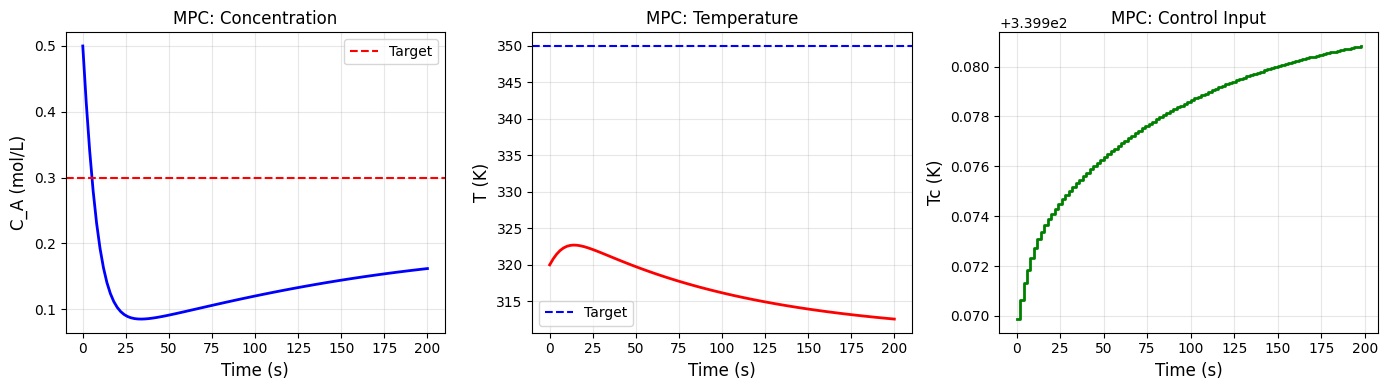


Final state: C_A = 0.1617, T = 312.57 K
Target:      C_A = 0.3000, T = 350.00 K


In [14]:
# Plot MPC results

t_mpc = jnp.arange(n_mpc_steps + 1) * dt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(t_mpc, mpc_states[:, 0], 'b-', linewidth=2)
axes[0].axhline(target[0], color='r', linestyle='--', label='Target')
axes[0].set_xlabel('Time (s)', fontsize=12)
axes[0].set_ylabel('C_A (mol/L)', fontsize=12)
axes[0].set_title('MPC: Concentration', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_mpc, mpc_states[:, 1], 'r-', linewidth=2)
axes[1].axhline(target[1], color='b', linestyle='--', label='Target')
axes[1].set_xlabel('Time (s)', fontsize=12)
axes[1].set_ylabel('T (K)', fontsize=12)
axes[1].set_title('MPC: Temperature', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].step(t_mpc[:-1], mpc_controls, 'g-', linewidth=2, where='post')
axes[2].set_xlabel('Time (s)', fontsize=12)
axes[2].set_ylabel('Tc (K)', fontsize=12)
axes[2].set_title('MPC: Control Input', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal state: C_A = {mpc_states[-1, 0]:.4f}, T = {mpc_states[-1, 1]:.2f} K")
print(f"Target:      C_A = {target[0]:.4f}, T = {target[1]:.2f} K")

## Summary

**Key concepts:**

1. **Differentiating through dynamics:**
   - Compute gradients of trajectory cost w.r.t. controls
   - Enable gradient-based trajectory optimization

2. **Open-loop trajectory optimization:**
   - Optimize entire control sequence at once
   - Works for known initial state and deterministic dynamics

3. **PID tuning with gradients:**
   - Directly optimize PID gains
   - Consider custom cost functions (ISE, overshoot, settling time)

4. **Model Predictive Control:**
   - Rolling horizon optimization
   - Handles constraints naturally
   - Robust to model mismatch (re-optimizes each step)

**Chemical engineering applications:**
- Reactor temperature control
- Distillation column control
- Batch process optimization
- Startup/shutdown trajectories
- Grade transitions

**Advantages of differentiable approach:**
- No need for derivative-free optimization
- Scales to high-dimensional control spaces
- Can incorporate complex models (neural ODEs, etc.)
- Enables end-to-end learning (learn model + controller together)